<a href="https://colab.research.google.com/github/SiahCHangYEt/Diploma-Final-Year-Project/blob/main/IndividualAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Genetic Algorithm for Solving the Berlin52 TSP
This project implements a Genetic Algorithm (GA) from scratch to solve the Traveling Salesman Problem (TSP) using the Berlin52 dataset. The goal is to find the shortest possible route that visits 52 cities in Berlin exactly once and returns to the starting point.

🚀 Performance Summary
Best Distance Achieved: 7777.54

Global Optimum (Berlin52): 7542.00

Error Margin: ~3.1%

🛠️ Implementation Details
The algorithm utilizes the following evolutionary components:

Encoding: Permutation Encoding (52 City IDs).

Fitness Function: Total Euclidean distance between coordinates.

Selection: Tournament Selection (Size 3).

Crossover: Ordered Crossover (OX) to ensure valid permutations.

Mutation: Swap Mutation (Rate: 0.1).

Elitism: Preserves the best individual in each generation.

📋 Experimental Setup
Population Size: 1,000

Generations: 1,000

Dataset: TSPLIB Berlin52 (52 cities)

Environment: Python 3 (Google Colab)

📂 File Structure
TSP_Genetic_Algorithm.ipynb: The main notebook containing the code, data dictionary, and visualization.

history: A list logging the best distance found in each generation.

graph: Matplotlib output showing the convergence of the algorithm over 1,000 generations.

⚙️ How to Run
Open the file in Google Colab or Jupyter Notebook.

Ensure matplotlib and numpy are installed.

Run all cells sequentially.

The final output will display the best distance found and a convergence plot.

📊 Observations
The algorithm demonstrates a rapid initial improvement, followed by plateaus. The 0.1 mutation rate was found to be optimal for fine-tuning the results, outperforming higher mutation rates by allowing for better exploitation of high-quality path segments without excessive disruption.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
# Berlin52 Coordinates from TSPLIB
nodes = {
    1: (565.0, 575.0), 2: (25.0, 185.0), 3: (345.0, 750.0), 4: (945.0, 685.0),
    5: (845.0, 655.0), 6: (880.0, 660.0), 7: (25.0, 230.0), 8: (525.0, 1000.0),
    9: (580.0, 1175.0), 10: (650.0, 1130.0), 11: (1605.0, 620.0), 12: (1220.0, 580.0),
    13: (1465.0, 200.0), 14: (1530.0, 5.0), 15: (845.0, 680.0), 16: (725.0, 370.0),
    17: (145.0, 665.0), 18: (415.0, 635.0), 19: (510.0, 875.0), 20: (560.0, 365.0),
    21: (300.0, 465.0), 22: (520.0, 585.0), 23: (480.0, 415.0), 24: (835.0, 625.0),
    25: (975.0, 580.0), 26: (1215.0, 245.0), 27: (1320.0, 315.0), 28: (1250.0, 400.0),
    29: (660.0, 180.0), 30: (410.0, 250.0), 31: (420.0, 555.0), 32: (575.0, 665.0),
    33: (1150.0, 1160.0), 34: (700.0, 580.0), 35: (685.0, 595.0), 36: (685.0, 610.0),
    37: (770.0, 610.0), 38: (795.0, 645.0), 39: (720.0, 635.0), 40: (760.0, 650.0),
    41: (475.0, 960.0), 42: (95.0, 260.0), 43: (875.0, 920.0), 44: (700.0, 500.0),
    45: (555.0, 815.0), 46: (830.0, 485.0), 47: (1170.0, 65.0), 48: (830.0, 610.0),
    49: (605.0, 625.0), 50: (595.0, 360.0), 51: (1340.0, 725.0), 52: (1740.0, 245.0)
}

def get_distance(city1_id, city2_id):
    c1 = nodes[city1_id]
    c2 = nodes[city2_id]
    return math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)

def calculate_fitness(route, nodes):
    total_distance = 0

    # Loop through the route (from index 0 to second-to-last)
    for i in range(len(route) - 1):
        city_a_id = route[i]
        city_b_id = route[i+1]

        # Get coordinates from our dictionary
        city_a_coords = nodes[city_a_id]
        city_b_coords = nodes[city_b_id]

        # Euclidean Distance formula
        dist = math.sqrt((city_a_coords[0] - city_b_coords[0])**2 +
                         (city_a_coords[1] - city_b_coords[1])**2)
        total_distance += dist

    # ADD THE RETURN TRIP: From last city back to the first city
    last_city = nodes[route[-1]]
    first_city = nodes[route[0]]
    return_dist = math.sqrt((last_city[0] - first_city[0])**2 +
                            (last_city[1] - first_city[1])**2)
    total_distance += return_dist

    return total_distance

def create_individual():
  genes = list(nodes.keys())
  random.shuffle(genes)
  return genes

def selection(population, fitness_scores, tournament_size=3):
    # 1. Pick 'tournament_size' random candidates from the population
    selection_ix = random.sample(range(len(population)), tournament_size)

    # 2. Find which of those candidates has the best (lowest) distance
    # We look at the fitness_scores at those specific random indices
    best_ix = selection_ix[0]
    for ix in selection_ix:
        if fitness_scores[ix] < fitness_scores[best_ix]:
            best_ix = ix

    # 3. Return the winning individual (the "parent")
    return population[best_ix]

def ordered_crossover(p1, p2):
    size = len(p1)
    child = [None] * size

    # Step 1: Pick two random cut points
    start, end = sorted([random.randrange(size) for _ in range(2)])

    # Copy segment from p1
    child[start:end] = p1[start:end]

    # Step 2 & 3: Fill remaining from p2 in order
    p2_index = 0
    for i in range(size):
        if child[i] is None:
            while p2[p2_index] in child:
                p2_index += 1
            child[i] = p2[p2_index]

    return child

def mutate(individual, mutation_rate):
    # For every individual, we check against the mutation rate
    if random.random() < mutation_rate:
        # Pick two random indices
        idx1, idx2 = random.sample(range(len(individual)), 2)

        # Swap the cities at those positions
        individual[idx1], individual[idx2] = individual[idx2], individual[idx1]

    return individual


In [2]:
def run_ga(pop_size=100,generations=500,mutation_rate=0.05,tournament_size = 3):
  history = []

  population = [create_individual() for i in range(pop_size)]
  for gen in range(generations):
    distances = [calculate_fitness(individual, nodes) for individual in population]
    best_dist = min(distances)
    history.append(best_dist)

    best_ind = population[distances.index(best_dist)]
    new_pop = [best_ind]

    while len(new_pop) < pop_size:
      p1 = selection(population, distances,tournament_size)
      p2 = selection(population, distances,tournament_size)
      child = ordered_crossover(p1, p2)
      child = mutate(child, mutation_rate)
      new_pop.append(child)

    population = new_pop

    if gen % 50 == 0:
      print(f"Generation {gen}: Best Distance = {best_dist}")

  plt.plot(history)
  plt.title("GA Convergence for Berlin52")
  plt.xlabel("Generation")
  plt.ylabel("Best Distance (lower is better)")
  plt.show()
  plt.savefig('my_convergence_graph.png')



Generation 0: Best Distance = 25676.18143488599
Generation 50: Best Distance = 15353.471382743106
Generation 100: Best Distance = 12256.006287552924
Generation 150: Best Distance = 11727.909543703903
Generation 200: Best Distance = 11566.20721347213
Generation 250: Best Distance = 11143.82816603936
Generation 300: Best Distance = 10442.635477646856
Generation 350: Best Distance = 10186.191235897313
Generation 400: Best Distance = 9794.007827534931
Generation 450: Best Distance = 9619.44681032933


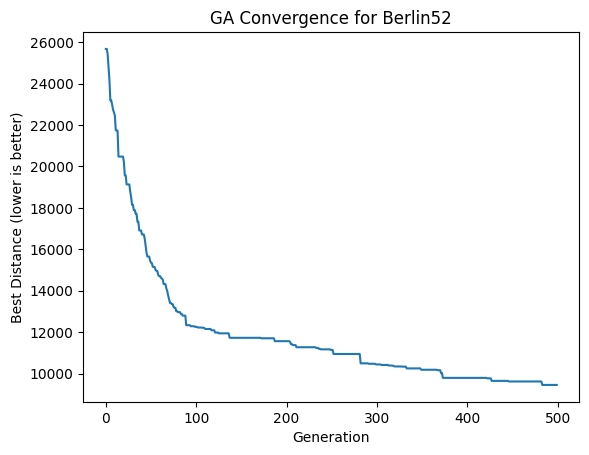

<Figure size 640x480 with 0 Axes>

In [3]:
run_ga()#default

Generation 0: Best Distance = 24085.30301755459
Generation 50: Best Distance = 13368.739922929808
Generation 100: Best Distance = 11871.65810573176
Generation 150: Best Distance = 8504.775295053716
Generation 200: Best Distance = 8480.719093003463
Generation 250: Best Distance = 8480.719093003463
Generation 300: Best Distance = 8480.719093003463
Generation 350: Best Distance = 8480.719093003463
Generation 400: Best Distance = 8480.719093003463
Generation 450: Best Distance = 8480.719093003463


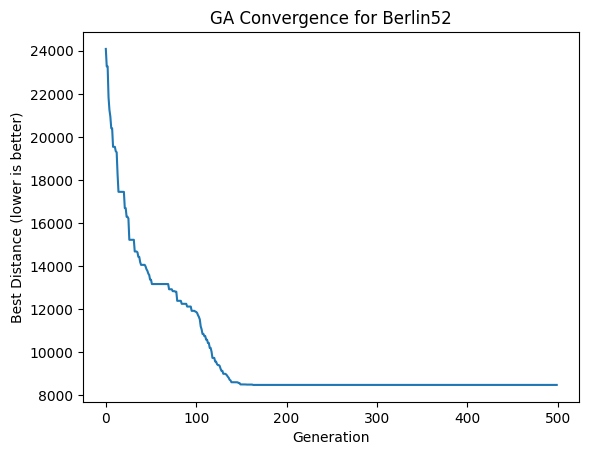

<Figure size 640x480 with 0 Axes>

In [4]:
run_ga(pop_size=1000,mutation_rate=0.1)

Generation 0: Best Distance = 24511.01572710499
Generation 50: Best Distance = 14176.743264483837
Generation 100: Best Distance = 12278.441202686867
Generation 150: Best Distance = 8845.357037958809
Generation 200: Best Distance = 8543.126416183566
Generation 250: Best Distance = 8543.126416183566
Generation 300: Best Distance = 8543.126416183566
Generation 350: Best Distance = 8543.126416183566
Generation 400: Best Distance = 8543.126416183566
Generation 450: Best Distance = 8543.126416183566


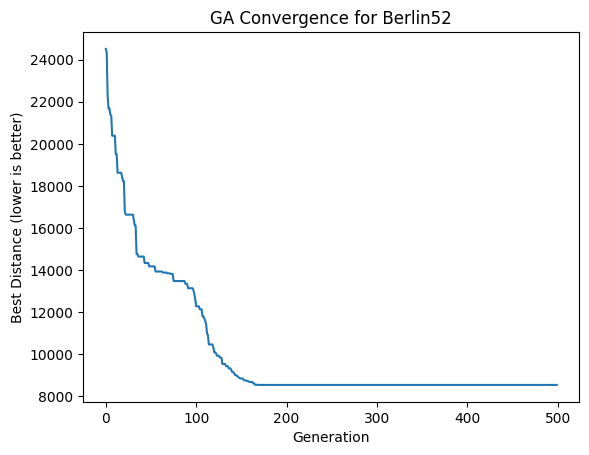

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga_2(pop_size=1000,mutation_rate=0.2,tournament_size=3)

Generation 0: Best Distance = 25583.634080564807
Generation 50: Best Distance = 14989.815505202794
Generation 100: Best Distance = 13822.383552884838
Generation 150: Best Distance = 13224.945909690474
Generation 200: Best Distance = 12762.721610051287
Generation 250: Best Distance = 12762.721610051287
Generation 300: Best Distance = 12672.543146129554
Generation 350: Best Distance = 12580.502670949836
Generation 400: Best Distance = 12418.460442624342
Generation 450: Best Distance = 12377.752960957416
Generation 500: Best Distance = 12370.971495553134
Generation 550: Best Distance = 12365.005838762696
Generation 600: Best Distance = 12006.576344881505
Generation 650: Best Distance = 11601.159030426836
Generation 700: Best Distance = 11601.159030426836
Generation 750: Best Distance = 11560.684603290267
Generation 800: Best Distance = 11542.10598003927
Generation 850: Best Distance = 11328.999922752437
Generation 900: Best Distance = 11288.808408443421
Generation 950: Best Distance = 112

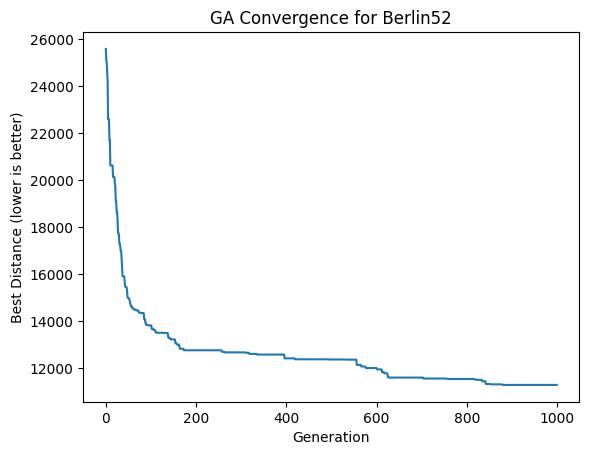

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga(generations=1000)#tournament size = 3

Generation 0: Best Distance = 24638.054770759278
Generation 50: Best Distance = 13823.220122631394
Generation 100: Best Distance = 12691.299177612129
Generation 150: Best Distance = 12075.25494062029
Generation 200: Best Distance = 11172.851434402633
Generation 250: Best Distance = 10024.87479981769
Generation 300: Best Distance = 9381.303325020142
Generation 350: Best Distance = 9001.603657997513
Generation 400: Best Distance = 8921.928045955854
Generation 450: Best Distance = 8921.77069934329
Generation 500: Best Distance = 8921.77069934329
Generation 550: Best Distance = 8921.77069934329
Generation 600: Best Distance = 8921.77069934329
Generation 650: Best Distance = 8921.77069934329
Generation 700: Best Distance = 8921.77069934329
Generation 750: Best Distance = 8921.77069934329
Generation 800: Best Distance = 8921.77069934329
Generation 850: Best Distance = 8921.77069934329
Generation 900: Best Distance = 8921.77069934329
Generation 950: Best Distance = 8921.77069934329


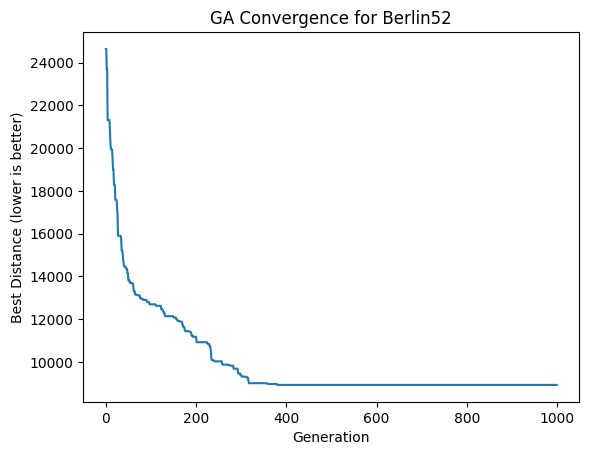

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga(generations=1000,mutation_rate=0.1)

Generation 0: Best Distance = 24855.09397076497
Generation 50: Best Distance = 13642.04282021644
Generation 100: Best Distance = 11285.159628173598
Generation 150: Best Distance = 9363.040409427038
Generation 200: Best Distance = 9138.446607589301
Generation 250: Best Distance = 9055.100650771023
Generation 300: Best Distance = 9055.100650771023
Generation 350: Best Distance = 9055.100650771023
Generation 400: Best Distance = 9055.100650771023
Generation 450: Best Distance = 9055.100650771023
Generation 500: Best Distance = 9055.100650771023
Generation 550: Best Distance = 9055.100650771023
Generation 600: Best Distance = 9055.100650771023
Generation 650: Best Distance = 9055.100650771023
Generation 700: Best Distance = 9055.100650771023
Generation 750: Best Distance = 9055.100650771023
Generation 800: Best Distance = 9055.100650771023
Generation 850: Best Distance = 9055.100650771023
Generation 900: Best Distance = 9055.100650771023
Generation 950: Best Distance = 9055.100650771023


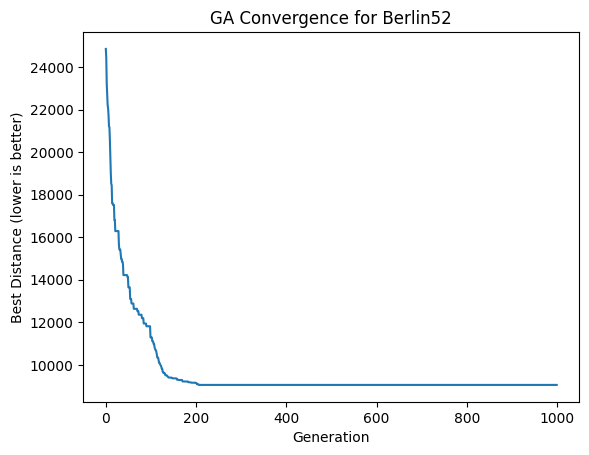

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga(pop_size=1000,generations=1000)

Generation 0: Best Distance = 24308.089093894072
Generation 50: Best Distance = 16585.377549374723
Generation 100: Best Distance = 15037.213553086207
Generation 150: Best Distance = 12511.789946009789
Generation 200: Best Distance = 9622.620186923381
Generation 250: Best Distance = 9114.938094963305
Generation 300: Best Distance = 9012.40091681567
Generation 350: Best Distance = 8933.680531273196
Generation 400: Best Distance = 8933.680531273196
Generation 450: Best Distance = 8933.680531273196
Generation 500: Best Distance = 8933.680531273196
Generation 550: Best Distance = 8933.680531273196
Generation 600: Best Distance = 8933.680531273196
Generation 650: Best Distance = 8933.680531273196
Generation 700: Best Distance = 8933.680531273196
Generation 750: Best Distance = 8933.680531273196
Generation 800: Best Distance = 8933.680531273196
Generation 850: Best Distance = 8933.680531273196
Generation 900: Best Distance = 8933.680531273196
Generation 950: Best Distance = 8933.680531273196


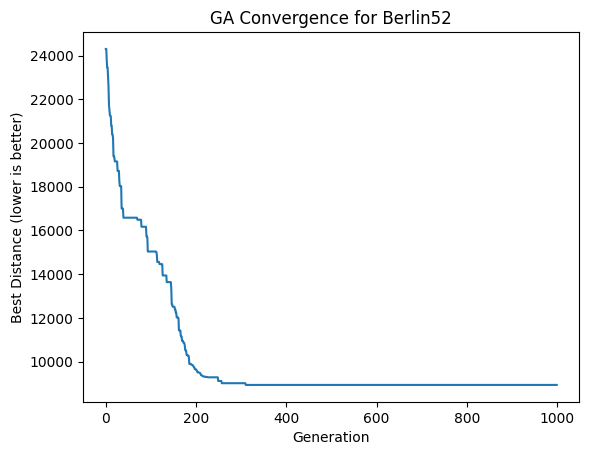

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga(pop_size = 1000,generations=1000)

Generation 0: Best Distance = 24863.444522312137
Generation 50: Best Distance = 15096.039870569777
Generation 100: Best Distance = 12922.684965783006
Generation 150: Best Distance = 9679.756237574384
Generation 200: Best Distance = 8876.113975207885
Generation 250: Best Distance = 8824.767268608604
Generation 300: Best Distance = 8824.767268608604
Generation 350: Best Distance = 8824.767268608604
Generation 400: Best Distance = 8824.767268608604
Generation 450: Best Distance = 8824.767268608604
Generation 500: Best Distance = 8824.767268608604
Generation 550: Best Distance = 8824.767268608604
Generation 600: Best Distance = 8824.767268608604
Generation 650: Best Distance = 8824.767268608604
Generation 700: Best Distance = 8824.767268608604
Generation 750: Best Distance = 8824.767268608604
Generation 800: Best Distance = 8824.767268608604
Generation 850: Best Distance = 8824.767268608604
Generation 900: Best Distance = 8824.767268608604
Generation 950: Best Distance = 8824.767268608604


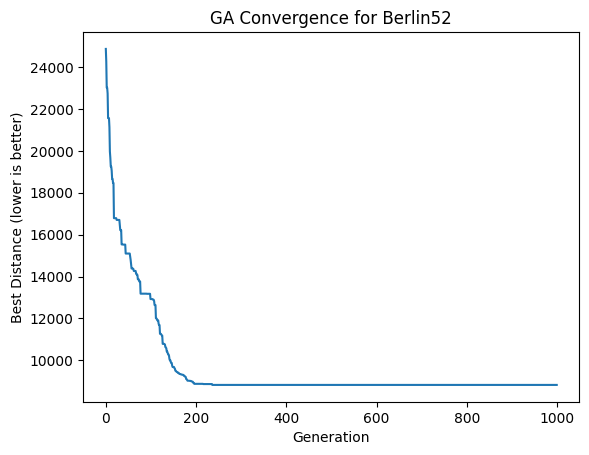

<Figure size 640x480 with 0 Axes>

In [5]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.2)

Generation 0: Best Distance = 22489.992051787583
Generation 50: Best Distance = 13650.757138505958
Generation 100: Best Distance = 9499.020922620055
Generation 150: Best Distance = 8267.73957901684
Generation 200: Best Distance = 8009.452241350444
Generation 250: Best Distance = 8009.452241350444
Generation 300: Best Distance = 7777.539883465208
Generation 350: Best Distance = 7777.539883465208
Generation 400: Best Distance = 7777.539883465208
Generation 450: Best Distance = 7777.539883465208
Generation 500: Best Distance = 7777.539883465208
Generation 550: Best Distance = 7777.539883465208
Generation 600: Best Distance = 7777.539883465208
Generation 650: Best Distance = 7777.539883465208
Generation 700: Best Distance = 7777.539883465208
Generation 750: Best Distance = 7777.539883465208
Generation 800: Best Distance = 7777.539883465208
Generation 850: Best Distance = 7777.539883465208
Generation 900: Best Distance = 7777.539883465208
Generation 950: Best Distance = 7777.539883465208


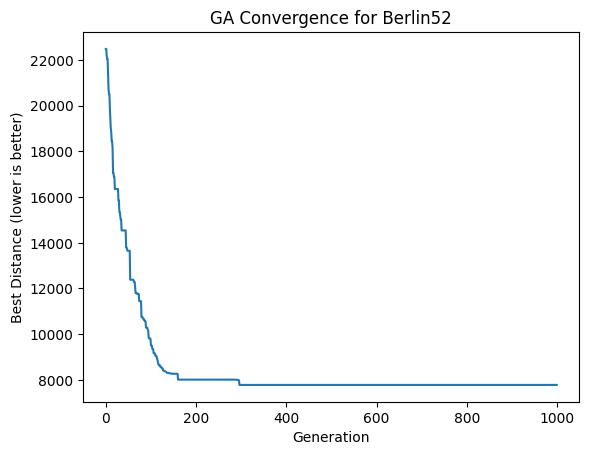

<Figure size 640x480 with 0 Axes>

In [6]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.1)

Generation 0: Best Distance = 24289.819272719535
Generation 50: Best Distance = 13503.268227285096
Generation 100: Best Distance = 9960.955207417339
Generation 150: Best Distance = 8277.02443184748
Generation 200: Best Distance = 8277.02443184748
Generation 250: Best Distance = 8277.02443184748
Generation 300: Best Distance = 8277.02443184748
Generation 350: Best Distance = 8277.02443184748
Generation 400: Best Distance = 8277.02443184748
Generation 450: Best Distance = 8277.02443184748
Generation 500: Best Distance = 8277.02443184748
Generation 550: Best Distance = 8277.02443184748
Generation 600: Best Distance = 8277.02443184748
Generation 650: Best Distance = 8277.02443184748
Generation 700: Best Distance = 8277.02443184748
Generation 750: Best Distance = 8277.02443184748
Generation 800: Best Distance = 8277.02443184748
Generation 850: Best Distance = 8277.02443184748
Generation 900: Best Distance = 8277.02443184748
Generation 950: Best Distance = 8277.02443184748


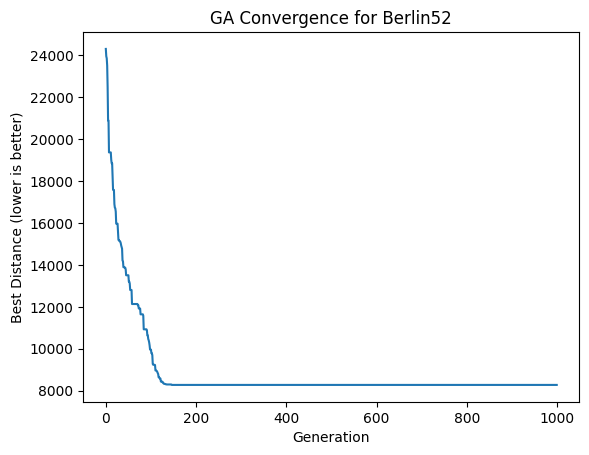

<Figure size 640x480 with 0 Axes>

In [7]:
run_ga(pop_size=1000,generations = 1000)

Generation 0: Best Distance = 24229.72279584832
Generation 50: Best Distance = 14916.335536627654
Generation 100: Best Distance = 10702.619513695397
Generation 150: Best Distance = 8256.422440320388
Generation 200: Best Distance = 8249.3473594036
Generation 250: Best Distance = 8249.3473594036
Generation 300: Best Distance = 8249.3473594036
Generation 350: Best Distance = 8249.3473594036
Generation 400: Best Distance = 8249.3473594036
Generation 450: Best Distance = 8249.3473594036


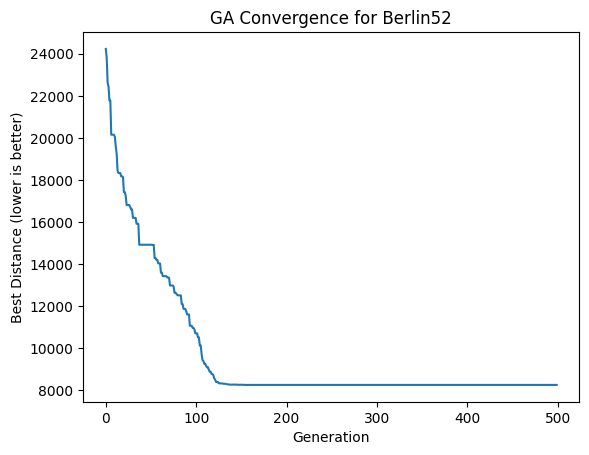

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga(pop_size=1000,mutation_rate=0.2)

Generation 0: Best Distance = 24164.375695443898
Generation 50: Best Distance = 13010.248004340707
Generation 100: Best Distance = 8773.332461062408
Generation 150: Best Distance = 8623.212338391835
Generation 200: Best Distance = 8623.212338391835
Generation 250: Best Distance = 8623.212338391835
Generation 300: Best Distance = 8623.212338391835
Generation 350: Best Distance = 8623.212338391835
Generation 400: Best Distance = 8623.212338391835
Generation 450: Best Distance = 8623.212338391835
Generation 500: Best Distance = 8623.212338391835
Generation 550: Best Distance = 8623.212338391835
Generation 600: Best Distance = 8623.212338391835
Generation 650: Best Distance = 8623.212338391835
Generation 700: Best Distance = 8623.212338391835
Generation 750: Best Distance = 8623.212338391835
Generation 800: Best Distance = 8623.212338391835
Generation 850: Best Distance = 8623.212338391835
Generation 900: Best Distance = 8623.212338391835
Generation 950: Best Distance = 8623.212338391835


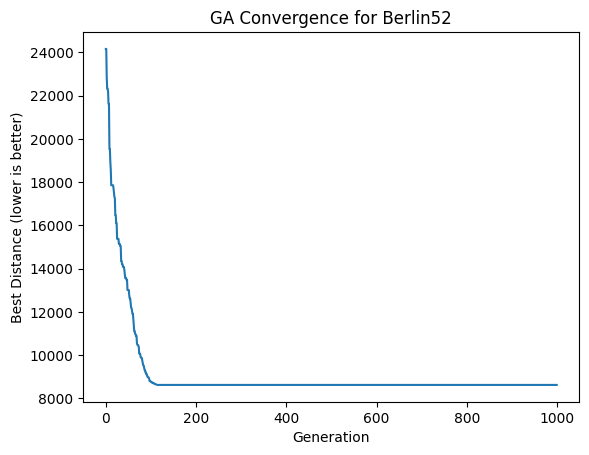

<Figure size 640x480 with 0 Axes>

In [9]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.1)

Generation 0: Best Distance = 24653.589547981628
Generation 50: Best Distance = 12500.5822682243
Generation 100: Best Distance = 8562.666889246844
Generation 150: Best Distance = 8502.94042824417
Generation 200: Best Distance = 8502.94042824417
Generation 250: Best Distance = 8502.94042824417
Generation 300: Best Distance = 8502.94042824417
Generation 350: Best Distance = 8502.94042824417
Generation 400: Best Distance = 8502.94042824417
Generation 450: Best Distance = 8502.94042824417


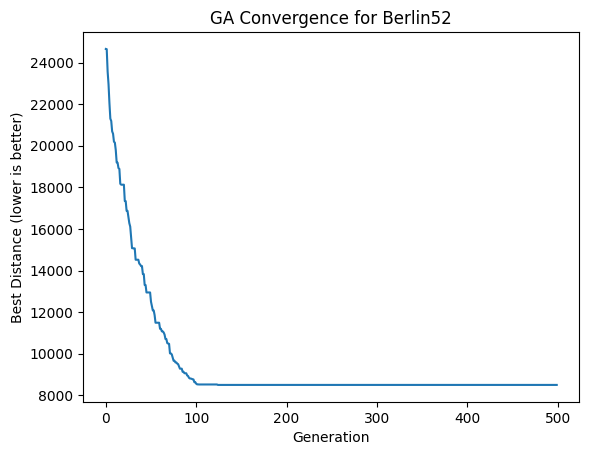

<Figure size 640x480 with 0 Axes>

In [8]:
run_ga(pop_size=1000,mutation_rate=0.1)

Generation 0: Best Distance = 25038.774876820007
Generation 50: Best Distance = 14166.082765989884
Generation 100: Best Distance = 9722.901819754414
Generation 150: Best Distance = 8279.948949333675
Generation 200: Best Distance = 8279.948949333675
Generation 250: Best Distance = 8279.948949333675
Generation 300: Best Distance = 8279.948949333675
Generation 350: Best Distance = 8097.99108879815
Generation 400: Best Distance = 8097.99108879815
Generation 450: Best Distance = 8097.99108879815


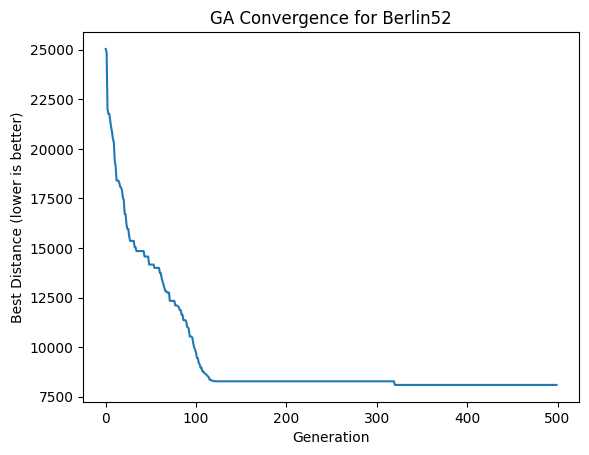

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga(pop_size=1000)

Generation 0: Best Distance = 24588.62845100256
Generation 50: Best Distance = 13648.004420348094
Generation 100: Best Distance = 11676.982374481617
Generation 150: Best Distance = 10141.559061358428
Generation 200: Best Distance = 8511.463245940482
Generation 250: Best Distance = 8372.499795029617
Generation 300: Best Distance = 8356.15776090769
Generation 350: Best Distance = 8356.15776090769
Generation 400: Best Distance = 8356.15776090769
Generation 450: Best Distance = 8356.15776090769


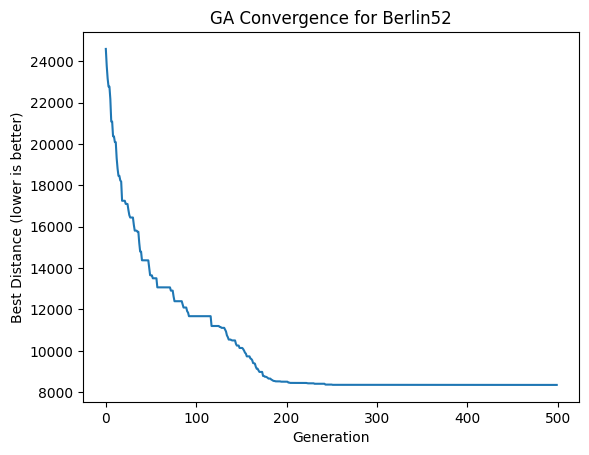

<Figure size 640x480 with 0 Axes>

In [ ]:
run_ga(pop_size=1000)

Generation 0: Best Distance = 24788.547784621067
Generation 50: Best Distance = 13972.000950834847
Generation 100: Best Distance = 9775.447889231253
Generation 150: Best Distance = 8530.756281518119
Generation 200: Best Distance = 8457.643184449122
Generation 250: Best Distance = 8457.643184449122
Generation 300: Best Distance = 8457.643184449122
Generation 350: Best Distance = 8457.643184449122
Generation 400: Best Distance = 8457.643184449122
Generation 450: Best Distance = 8457.643184449122
Generation 500: Best Distance = 8457.643184449122
Generation 550: Best Distance = 8457.643184449122
Generation 600: Best Distance = 8457.643184449122
Generation 650: Best Distance = 8457.643184449122
Generation 700: Best Distance = 8457.643184449122
Generation 750: Best Distance = 8457.643184449122
Generation 800: Best Distance = 8457.643184449122
Generation 850: Best Distance = 8457.643184449122
Generation 900: Best Distance = 8457.643184449122
Generation 950: Best Distance = 8457.643184449122


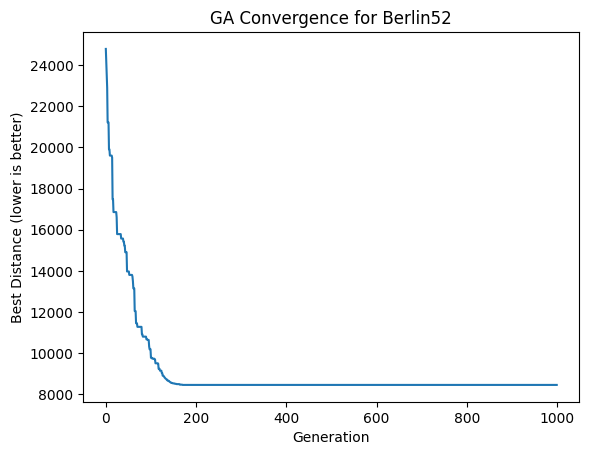

<Figure size 640x480 with 0 Axes>

In [12]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.2)

Generation 0: Best Distance = 24910.35842629781
Generation 50: Best Distance = 14619.45712599437
Generation 100: Best Distance = 12597.555541122525
Generation 150: Best Distance = 12066.69104554606
Generation 200: Best Distance = 11098.683483557697
Generation 250: Best Distance = 8609.7596259306
Generation 300: Best Distance = 8403.996307019528
Generation 350: Best Distance = 8376.84833289525
Generation 400: Best Distance = 8376.84833289525
Generation 450: Best Distance = 8376.84833289525
Generation 500: Best Distance = 8376.84833289525
Generation 550: Best Distance = 8376.84833289525
Generation 600: Best Distance = 8376.84833289525
Generation 650: Best Distance = 8376.84833289525
Generation 700: Best Distance = 8376.84833289525
Generation 750: Best Distance = 8376.84833289525
Generation 800: Best Distance = 8302.061133418192
Generation 850: Best Distance = 8302.061133418192
Generation 900: Best Distance = 8302.061133418192
Generation 950: Best Distance = 8302.061133418192


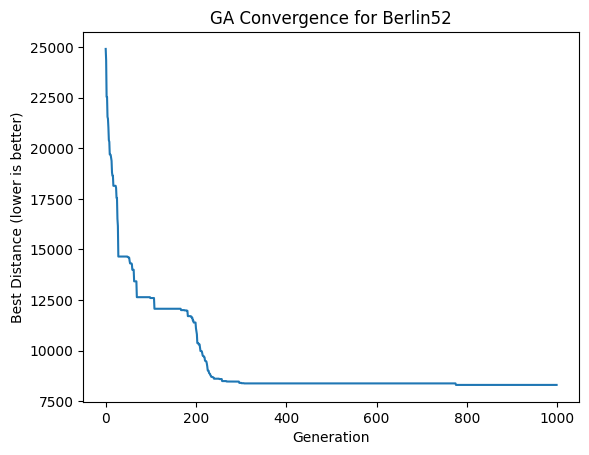

<Figure size 640x480 with 0 Axes>

In [13]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.2)

Generation 0: Best Distance = 24189.479911501952
Generation 50: Best Distance = 13625.851597307203
Generation 100: Best Distance = 9193.13987639371
Generation 150: Best Distance = 9118.24012120556
Generation 200: Best Distance = 8960.428520630941
Generation 250: Best Distance = 8960.428520630941
Generation 300: Best Distance = 8960.428520630941
Generation 350: Best Distance = 8960.428520630941
Generation 400: Best Distance = 8960.428520630941
Generation 450: Best Distance = 8960.428520630941
Generation 500: Best Distance = 8960.428520630941
Generation 550: Best Distance = 8960.428520630941
Generation 600: Best Distance = 8960.428520630941
Generation 650: Best Distance = 8960.428520630941
Generation 700: Best Distance = 8960.428520630941
Generation 750: Best Distance = 8940.767695377981
Generation 800: Best Distance = 8940.767695377981
Generation 850: Best Distance = 8940.767695377981
Generation 900: Best Distance = 8940.767695377981
Generation 950: Best Distance = 8940.767695377981


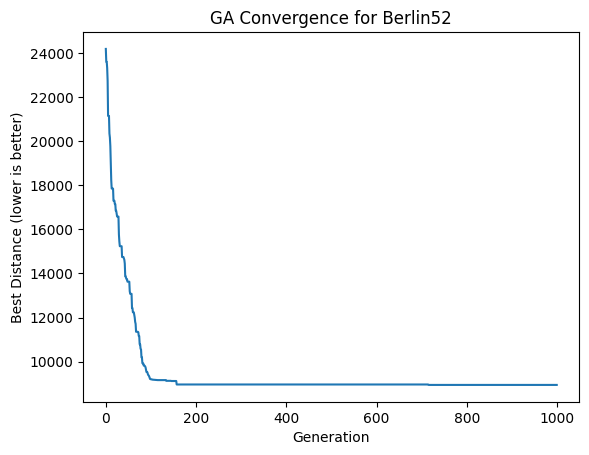

<Figure size 640x480 with 0 Axes>

In [14]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.1)

Generation 0: Best Distance = 24731.39054829493
Generation 50: Best Distance = 13486.417256376044
Generation 100: Best Distance = 9051.602790034582
Generation 150: Best Distance = 8624.640854142039
Generation 200: Best Distance = 8617.56577322525
Generation 250: Best Distance = 8617.56577322525
Generation 300: Best Distance = 8567.745334895024
Generation 350: Best Distance = 8529.64808244925
Generation 400: Best Distance = 8529.64808244925
Generation 450: Best Distance = 8529.64808244925
Generation 500: Best Distance = 8529.64808244925
Generation 550: Best Distance = 8529.64808244925
Generation 600: Best Distance = 8529.64808244925
Generation 650: Best Distance = 8529.64808244925
Generation 700: Best Distance = 8475.571643448799
Generation 750: Best Distance = 8475.571643448799
Generation 800: Best Distance = 8475.571643448799
Generation 850: Best Distance = 8475.571643448799
Generation 900: Best Distance = 8475.571643448799
Generation 950: Best Distance = 8475.571643448799


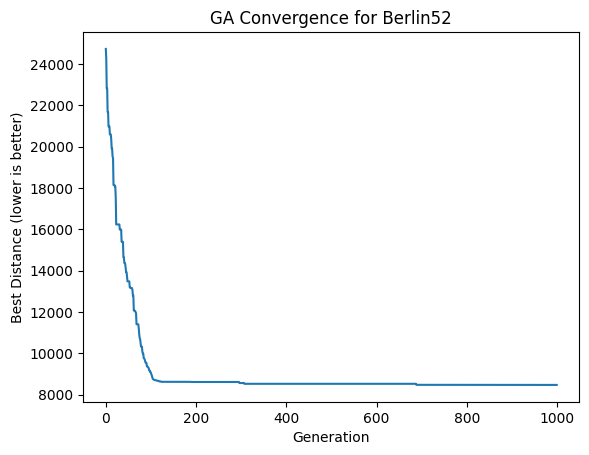

<Figure size 640x480 with 0 Axes>

In [15]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.2)

Generation 0: Best Distance = 24235.70011679429
Generation 50: Best Distance = 12826.120661338195
Generation 100: Best Distance = 8784.58243310482
Generation 150: Best Distance = 8705.042516367319
Generation 200: Best Distance = 8555.924045583739
Generation 250: Best Distance = 8491.335820727685
Generation 300: Best Distance = 8491.335820727685
Generation 350: Best Distance = 8491.335820727685
Generation 400: Best Distance = 8491.335820727685
Generation 450: Best Distance = 8491.335820727685
Generation 500: Best Distance = 8491.335820727685
Generation 550: Best Distance = 8491.335820727685
Generation 600: Best Distance = 8491.335820727685
Generation 650: Best Distance = 8491.335820727685
Generation 700: Best Distance = 8491.335820727685
Generation 750: Best Distance = 8491.335820727685
Generation 800: Best Distance = 8491.335820727685
Generation 850: Best Distance = 8491.335820727685
Generation 900: Best Distance = 8491.335820727685
Generation 950: Best Distance = 8491.335820727685


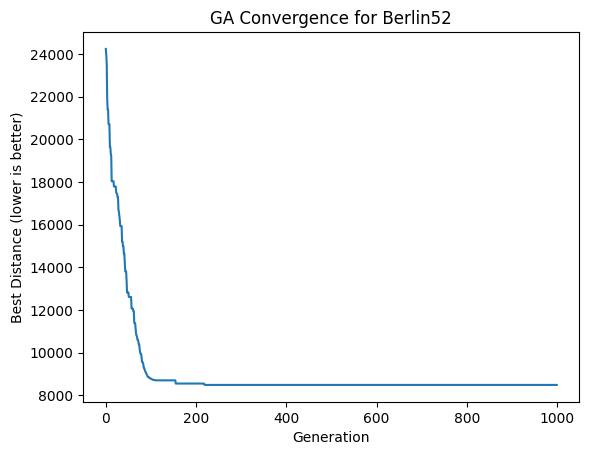

<Figure size 640x480 with 0 Axes>

In [16]:
run_ga(pop_size=1000,generations=1000,mutation_rate=0.05)